In [1]:
import pandas as pd
import csv
import ast

df = pd.read_csv(
    "processed_vaccine_tweets.csv",
    engine="python",
    on_bad_lines="skip",
    sep=",",
    quotechar='"',
    escapechar="\\"
)

print(df.shape)
print(df.columns)

(227317, 33)
Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet', 'account_age_days', 'clean_text', 'text_length',
       'word_count', 'hashtag_count', 'engagement', 'followers_log',
       'friends_log', 'verified_user', 'sentiment', 'exclamation_count',
       'question_count', 'hour', 'day_of_week', 'month', 'hashtag_list',
       'high_amplification'],
      dtype='object')


In [2]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# remove rows where date failed to parse
df = df[df['date'].notna()]

print("Date column cleaned")
print(df['date'].head())

Date column cleaned
0   2020-12-20 06:06:44
1   2020-12-13 16:27:13
2   2020-12-12 20:33:45
3   2020-12-12 20:23:59
4   2020-12-12 20:17:19
Name: date, dtype: datetime64[ns]


In [3]:
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce')
df['favorites'] = pd.to_numeric(df['favorites'], errors='coerce')

df = df[df['retweets'].notna() & df['favorites'].notna()]

df['engagement'] = df['retweets'] + df['favorites']

In [4]:
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce').fillna(0)
df['favorites'] = pd.to_numeric(df['favorites'], errors='coerce').fillna(0)

df['engagement'] = df['retweets'] + df['favorites']

In [5]:
print(df[['retweets', 'favorites', 'engagement']].dtypes)
print(df[['retweets', 'favorites', 'engagement']].head())

retweets      float64
favorites     float64
engagement    float64
dtype: object
   retweets  favorites  engagement
0       0.0        0.0         0.0
1       1.0        1.0         2.0
2       0.0        0.0         0.0
3     446.0     2129.0      2575.0
4       0.0        0.0         0.0


In [6]:
df['engagement'] = df['retweets'] + df['favorites']

In [7]:
threshold = df['engagement'].quantile(0.90)
df['viral'] = (df['engagement'] >= threshold).astype(int)

print("Viral threshold:", threshold)
print(df['viral'].value_counts(normalize=True))

Viral threshold: 12.0
viral
0    0.899252
1    0.100748
Name: proportion, dtype: float64


In [8]:
# convert to datetime safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['user_created'] = pd.to_datetime(df['user_created'], errors='coerce')

# remove rows where conversion failed
df = df[df['date'].notna() & df['user_created'].notna()]

# reset index
df = df.reset_index(drop=True)

<Axes: title={'center': 'Tweet Activity Over Time'}, xlabel='date'>

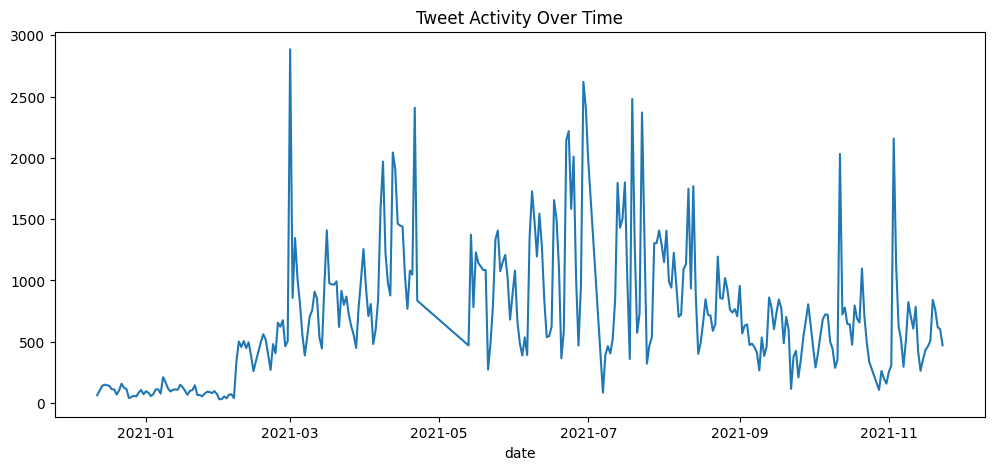

In [9]:
df['date'] = pd.to_datetime(df['date'])

tweets_per_day = df.groupby(df['date'].dt.date).size()

tweets_per_day.plot(figsize=(12,5), title="Tweet Activity Over Time")

<Axes: title={'center': 'Average Engagement Over Time'}, xlabel='date'>

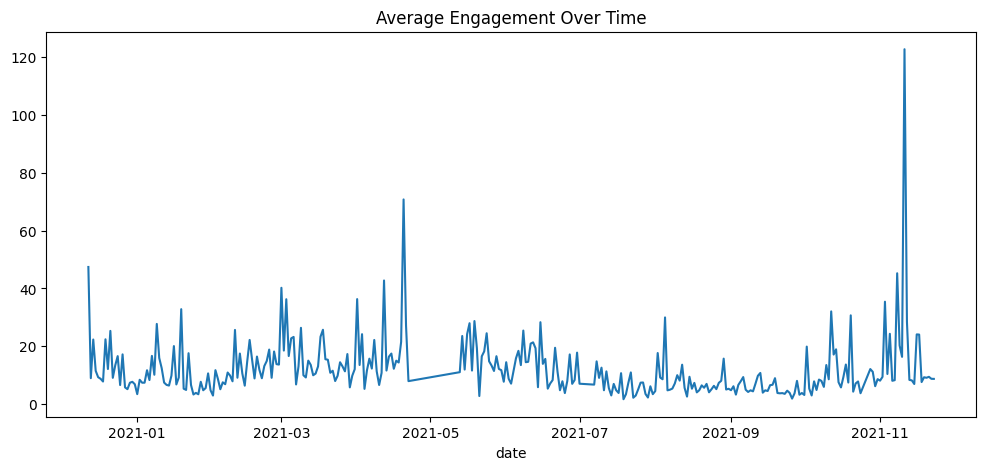

In [10]:
engagement_per_day = df.groupby(df['date'].dt.date)['engagement'].mean()

engagement_per_day.plot(figsize=(12,5), title="Average Engagement Over Time")

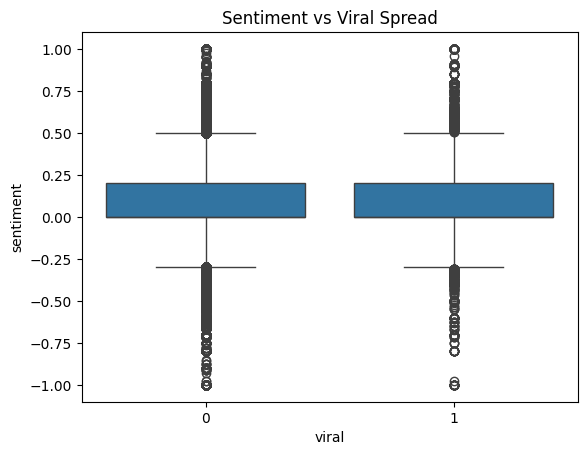

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='viral', y='sentiment', data=df)

plt.title("Sentiment vs Viral Spread")
plt.show()

In [12]:
hashtags_df = df.explode('hashtag_list')
hashtags_df = hashtags_df[hashtags_df['hashtag_list'].notna()]
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].astype(str).str.lower().str.strip()

top_hashtags = hashtags_df['hashtag_list'].value_counts().head(20)
print(top_hashtags)

hashtag_list
[]                                                                   48798
["['covaxin']"]                                                      22738
["['moderna']"]                                                      13139
["['covaxin',", "'bbmp']"]                                           11116
["['sputnikv']"]                                                      5816
["['sinovac']"]                                                       3123
["['sinopharm']"]                                                     2924
["['bbmp',", "'bengaluru',", "'covidvaccine',", "'covishield']"]      2922
["['urban',", "'bengaluru',", "'covidvaccine',", "'covishield']"]     2690
["['covid19']"]                                                       1913
["['pfizerbiontech']"]                                                1813
["['pfizer',", "'moderna']"]                                          1522
["['covaxin',", "'gurgaoncovaxin']"]                                  1166
["['oxfordas

In [13]:
hashtag_engagement = (
    hashtags_df.groupby('hashtag_list')['engagement']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print(hashtag_engagement)

hashtag_list
["['vaccines',", "'covid19',", "'pfizer',", "'moderna',", "'vaccinessavelives',", "'vaccinated']"]                                 27317.000000
["['moderna',", "'covidvaccine',", "'thankyouscience',", "'imnotgonnacryincvs',", "'okimight',", "'dontjudge',", "'ithitsya']"]     8219.000000
["['teammolly',", "'themollyway',", "'covidvaccine',", "'booster',", "'thirdshot',", "'moderna',", "'stayhealthy']"]                3465.000000
["['pmmodi',", "'covaxin',", "'covishieldvaccine']"]                                                                                3345.000000
["['coronavirus',", "'oxfordvaccine']"]                                                                                             3228.000000
["['announce']"]                                                                                                                    2753.500000
["['covaxin',", "'navaraipur',", "'chhattisgarh']"]                                                                        

In [14]:
df['user_followers'] = pd.to_numeric(df['user_followers'], errors='coerce')
df['engagement'] = pd.to_numeric(df['engagement'], errors='coerce')

df = df[df['user_followers'].notna() & df['engagement'].notna()]

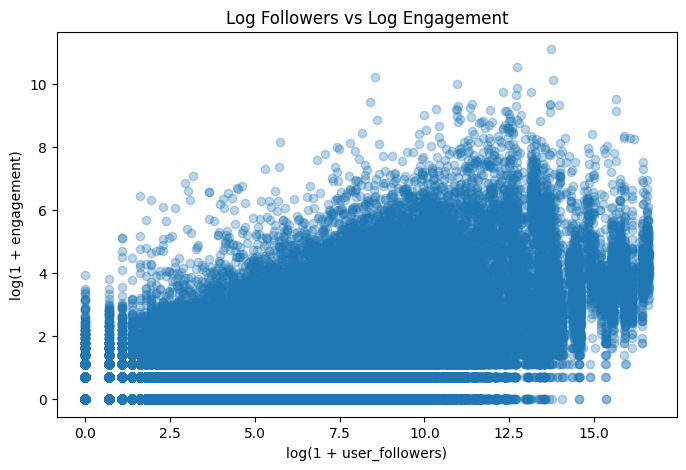

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    np.log1p(df['user_followers']),
    np.log1p(df['engagement']),
    alpha=0.3
)

plt.xlabel("log(1 + user_followers)")
plt.ylabel("log(1 + engagement)")
plt.title("Log Followers vs Log Engagement")

plt.show()

In [16]:
df[['user_followers','engagement']].corr()

,user_followers,engagement
user_followers,1.000000,0.045555
engagement,0.045555,1.000000


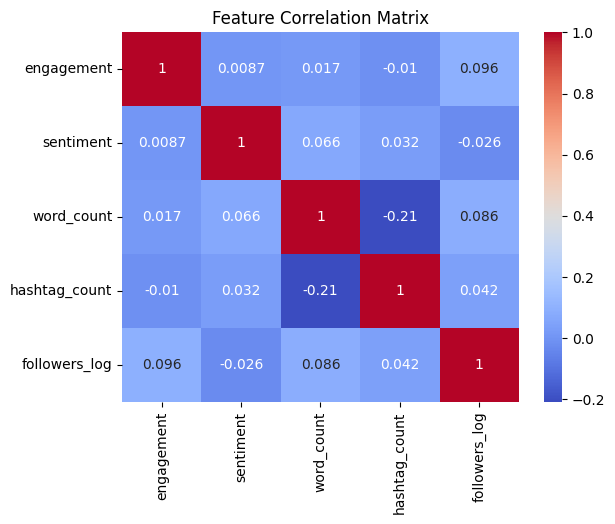

In [17]:
corr = df[[
    'engagement',
    'sentiment',
    'word_count',
    'hashtag_count',
    'followers_log'
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

features = ['sentiment', 'word_count', 'hashtag_count', 'followers_log']
X = df[features]
y = df['viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[39563  1314]
 [ 3045  1535]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     40877
           1       0.54      0.34      0.41      4580

    accuracy                           0.90     45457
   macro avg       0.73      0.65      0.68     45457
weighted avg       0.89      0.90      0.89     45457



In [19]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

followers_log    0.714502
sentiment        0.137289
word_count       0.097519
hashtag_count    0.050690
dtype: float64


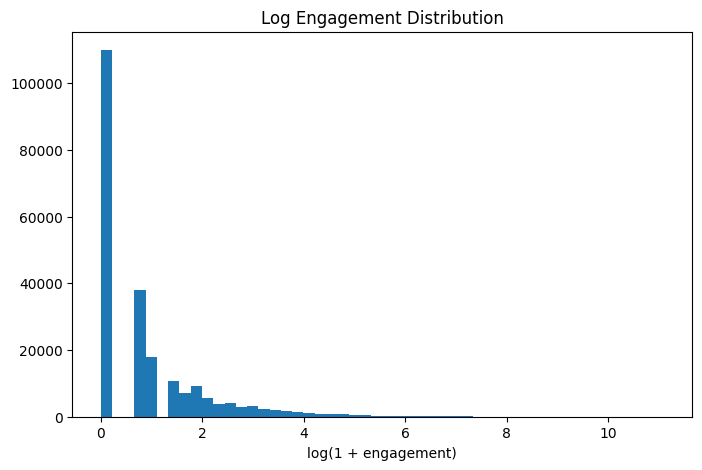

In [20]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['engagement']), bins=50)
plt.title("Log Engagement Distribution")
plt.xlabel("log(1 + engagement)")
plt.show()

In [21]:
import ast

def normalize_hashtag_list(x):
    # already a list
    if isinstance(x, list):
        tags = x
    # missing value
    elif pd.isna(x):
        return []
    # stringified list
    else:
        try:
            tags = ast.literal_eval(x)
        except:
            return []

    if not isinstance(tags, list):
        return []

    clean_tags = []
    for tag in tags:
        tag = str(tag).lower().strip()
        tag = tag.replace("[", "").replace("]", "").replace("'", "").replace('"', "").replace(",", "")
        if tag != "" and tag != "nan":
            clean_tags.append(tag)

    return clean_tags

df['hashtag_list_clean'] = df['hashtag_list'].apply(normalize_hashtag_list)

In [22]:
hashtags_df = df.explode('hashtag_list_clean')
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'].notna()]
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'] != ""]
hashtags_df = hashtags_df[hashtags_df['hashtag_list_clean'] != "nan"]

top_hashtags = hashtags_df['hashtag_list_clean'].value_counts().head(20)
print(top_hashtags)

hashtag_list_clean
covaxin           58657
moderna           44059
covid19           19323
sputnikv          14497
bbmp              14184
vaccine           13295
covidvaccine      12864
pfizer            12218
covishield        11432
sinovac           10377
sinopharm          8301
bengaluru          7025
pfizerbiontech     6548
covid              4775
astrazeneca        3925
vaccinated         3898
vaccines           3391
coronavirus        2777
urban              2769
covid19vaccine     2751
Name: count, dtype: int64


In [23]:
hashtag_engagement = (
    hashtags_df.groupby('hashtag_list_clean')['engagement']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print(hashtag_engagement)

hashtag_list_clean
dontjudge             8219.000000
ithitsya              8219.000000
imnotgonnacryincvs    8219.000000
okimight              8219.000000
themollyway           3465.000000
navaraipur            2480.000000
announce              1836.333333
canadavaccinated      1785.000000
teammolly             1732.500000
cardano               1370.000000
idclab                1365.000000
4th                   1016.000000
russiaday              976.000000
multiplemyeloma        962.250000
overcast               957.000000
onmywalk               957.000000
pharmacovigilance      886.000000
disabledandcute        829.000000
karakattakkaran        822.000000
pakfightscovid         800.000000
Name: engagement, dtype: float64
